# EDA — Exchange (the iteration dataset)

**Probabilistic Time-Series Forecasting with Diffusion Models — PML, Univ. Trieste.**

This notebook explores **Exchange** (8 currencies vs USD, daily), the small dataset
on which we bring the whole pipeline green *before* scaling to the primary dataset
(plan §4.3). It runs on the **same data contract** every model consumes
(`src/data/exchange.py`), so what we see here is exactly what the models see.

**What we look for (and why it matters for the project):**
1. The raw series & the train/val/test split.
2. Stationarity / unit root (ADF) — does a *naive last-value* forecast become a hard baseline?
3. Autocorrelation (ACF/PACF) of levels vs log-returns.
4. Volatility clustering — heteroskedasticity the models must handle.
5. Heavy tails of returns.
6. Calendar seasonality (spoiler: weak here — a teaching contrast with Solar/Electricity).
7. Regime-shift candidates for the robustness experiment **E4**.

A short written synthesis lives in [`docs/EDA_EXCHANGE.md`](../docs/EDA_EXCHANGE.md).
Figures are saved to `figures/`; key numbers to `results/eda_exchange_stats.json`.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from scipy.stats import kurtosis, skew, norm

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

# Find the repo root whether the notebook runs from repo/ or repo/notebooks/.
REPO = Path.cwd()
while not (REPO / "src" / "data" / "exchange.py").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
FIG = REPO / "figures"; FIG.mkdir(exist_ok=True)
print("repo root:", REPO)

repo root: /Users/giovannimason/Desktop/pml-diffusion-tsf


## 1. Load via the data contract

In [2]:
from src.utils.config import load_config
from src.data.exchange import load_exchange

cfg = load_config(REPO / "configs" / "data_exchange.yaml")
ds = load_exchange(cfg)   # downloads on first run (cached in data/raw/, gitignored)

# Reassemble the original-scale series for interpretable EDA, with a NOMINAL daily index.
full = np.concatenate([ds.raw_splits[s] for s in ("train", "val", "test")], axis=0)
idx = pd.date_range(cfg["source"]["start_date"], periods=len(full), freq=cfg["source"]["freq"])
df = pd.DataFrame(full, index=idx, columns=[f"ccy{i}" for i in range(ds.D)])
n_tr = ds.raw_splits["train"].shape[0]
n_va = ds.raw_splits["val"].shape[0]
n_te = len(df) - n_tr - n_va
print(f"D={ds.D}  H(context)={ds.H}  tau(horizon)={ds.tau}")
print(f"total={len(df)}  ->  train={n_tr}  val={n_va}  test={n_te}  (70/10/20, time-ordered)")
df.head()

D=8  H(context)=60  tau(horizon)=30
total=7588  ->  train=5311  val=758  test=1519  (70/10/20, time-ordered)


,ccy0,ccy1,ccy2,ccy3,ccy4,ccy5,ccy6,ccy7
1990-01-01,0.7855,1.6110,0.861698,0.634196,0.211242,0.006838,0.5930,0.525486
1990-01-02,0.7818,1.6100,0.861104,0.633513,0.211242,0.006863,0.5940,0.523972
1990-01-03,0.7867,1.6293,0.861030,0.648508,0.211242,0.006975,0.5973,0.526316
1990-01-04,0.7860,1.6370,0.862069,0.650618,0.211242,0.006953,0.5970,0.523834
1990-01-05,0.7849,1.6530,0.861995,0.656254,0.211242,0.006940,0.5985,0.527426


> **Note on timestamps.** The raw Exchange file ships *without dates* — it is a
> sequence of daily observations. We attach a **nominal** `DatetimeIndex` starting
> 1990-01-01 purely for plotting and (later) calendar covariates. Absolute dates are
> not meaningful, so we never read real-world events off them; we treat the index as
> "trading day *t*".

## 2. The raw series and the split

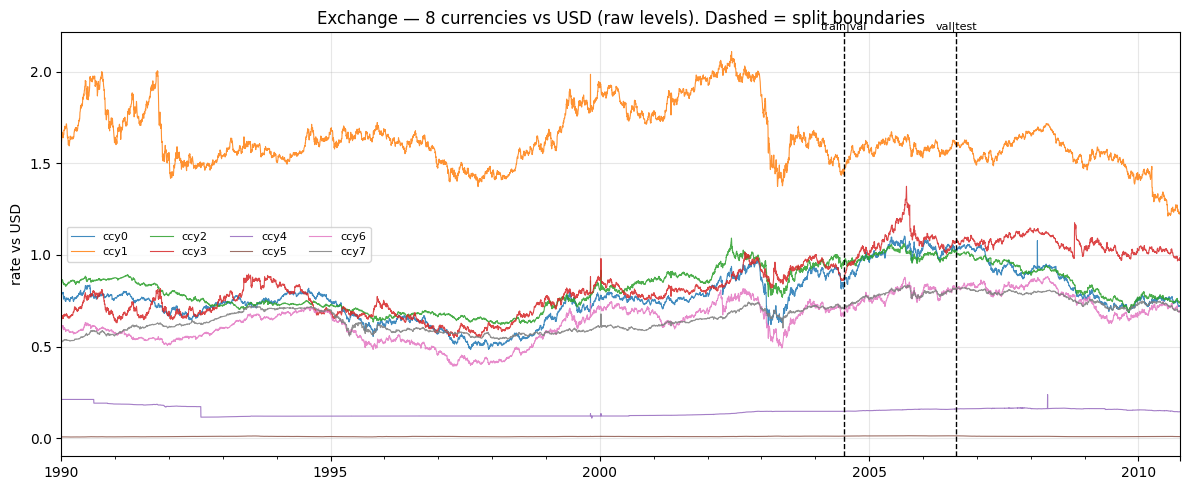

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
df.plot(ax=ax, lw=0.8, alpha=0.85)
for b, lab in [(n_tr, "train|val"), (n_tr + n_va, "val|test")]:
    ax.axvline(df.index[b], color="k", ls="--", lw=1)
    ax.text(df.index[b], ax.get_ylim()[1], lab, fontsize=8, ha="center", va="bottom")
ax.set_title("Exchange — 8 currencies vs USD (raw levels). Dashed = split boundaries")
ax.set_ylabel("rate vs USD"); ax.legend(ncol=4, fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "eda_exchange_series.png", dpi=120); plt.show()

The series **wander** with persistent trends and no fixed mean — visually a random
walk, not a mean-reverting seasonal signal. The most-recent 20 % (test) sits in a
different region than train for several currencies: a real but mild **distribution
shift** the models must extrapolate into.

## 3. Stationarity / unit root (ADF test)

In [4]:
# Daily log-returns: diff of log-levels (all rates are > 0).
def logret(x):
    return np.diff(np.log(x), axis=0)

rows = []
for c in df.columns:
    lv = df[c].values
    rows.append({
        "series": c,
        "adf_p_levels": adfuller(lv, autolag="AIC")[1],
        "adf_p_logret": adfuller(logret(lv), autolag="AIC")[1],
    })
adf = pd.DataFrame(rows).set_index("series")
adf["levels_nonstationary (p>0.05)"] = adf["adf_p_levels"] > 0.05
adf["returns_stationary (p<0.05)"] = adf["adf_p_logret"] < 0.05
adf.round(4)

,adf_p_levels,adf_p_logret,levels_nonstationary (p>0.05),returns_stationary (p<0.05)
series,,,,
ccy0,0.4492,0.0,True,True
ccy1,0.2250,0.0,True,True
ccy2,0.6048,0.0,True,True
ccy3,0.4903,0.0,True,True
ccy4,0.0491,0.0,False,True
ccy5,0.2365,0.0,True,True
ccy6,0.4166,0.0,True,True
ccy7,0.4067,0.0,True,True


**Levels** fail the ADF stationarity test for almost every currency (large p-values
⇒ a unit root), while **log-returns** are firmly stationary (p ≈ 0). This is the
classic random-walk signature of FX, and it has a direct project consequence:

> A **naive "tomorrow = today"** forecast is a genuinely hard baseline here (M0).
> Beating it must be *earned* — exactly the honesty anchor the plan wants (§5.1).

## 4. Autocorrelation — levels vs log-returns

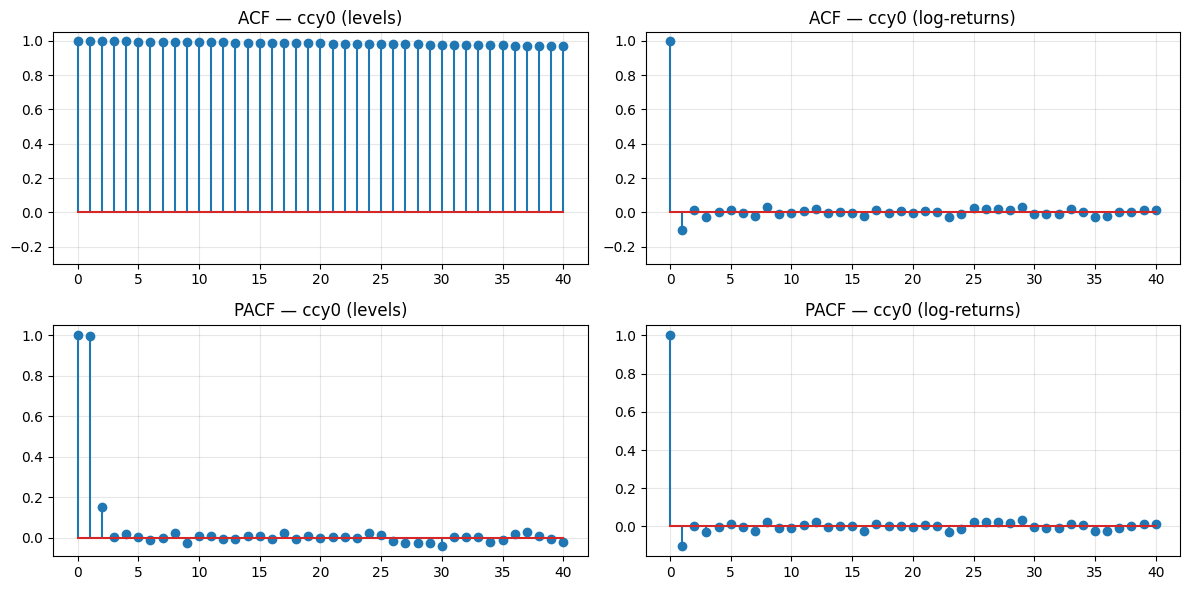

lag-1 ACF  levels = 0.9990   returns = -0.1010


In [5]:
c0 = df.columns[0]
lv = df[c0].values
lr = logret(lv)
nlags = 40
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, s, name in [(axes[0, 0], lv, "levels"), (axes[0, 1], lr, "log-returns")]:
    vals = acf(s, nlags=nlags)
    ax.stem(range(len(vals)), vals); ax.set_title(f"ACF — {c0} ({name})"); ax.set_ylim(-0.3, 1.05)
for ax, s, name in [(axes[1, 0], lv, "levels"), (axes[1, 1], lr, "log-returns")]:
    vals = pacf(s, nlags=nlags)
    ax.stem(range(len(vals)), vals); ax.set_title(f"PACF — {c0} ({name})")
fig.tight_layout(); fig.savefig(FIG / "eda_exchange_acf.png", dpi=120); plt.show()
print(f"lag-1 ACF  levels = {acf(lv, nlags=1)[1]:.4f}   returns = {acf(lr, nlags=1)[1]:.4f}")

Levels: ACF ≈ 1 decaying *extremely* slowly, PACF with a single spike at lag 1 ≈ 1 —
the textbook AR(1)-with-unit-root picture. Returns: ACF collapses to near-zero
immediately → returns are close to **white noise** in the mean. So there is little
linear signal in the *direction* of returns; the structure lives in their **variance**
(next section).

## 5. Volatility clustering (heteroskedasticity)

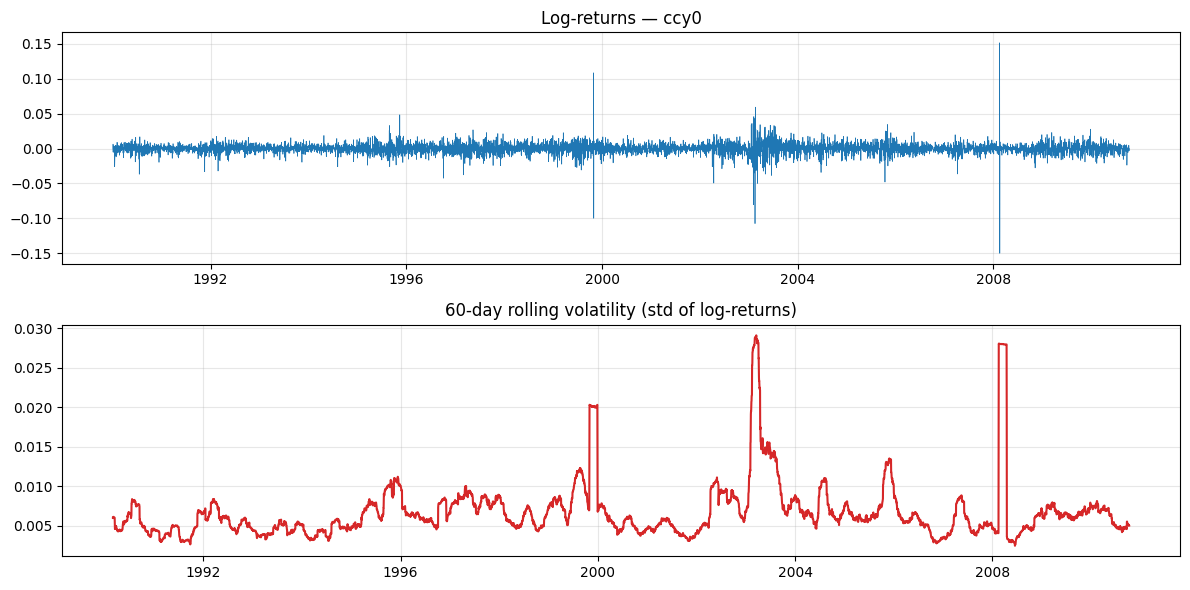

ACF of SQUARED returns at lags 1, 5, 10: [0.415, 0.02, 0.046]


In [6]:
roll = pd.Series(lr, index=df.index[1:]).rolling(60).std()
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(df.index[1:], lr, lw=0.5); axes[0].set_title(f"Log-returns — {c0}")
axes[1].plot(roll.index, roll.values, color="C3"); axes[1].set_title("60-day rolling volatility (std of log-returns)")
fig.tight_layout(); fig.savefig(FIG / "eda_exchange_volatility.png", dpi=120); plt.show()
acf_sq = acf(lr ** 2, nlags=20)
print("ACF of SQUARED returns at lags 1, 5, 10:", [round(acf_sq[k], 3) for k in (1, 5, 10)])

Returns themselves are unpredictable, but their **magnitude** is not: squared returns
are positively autocorrelated (lag-1 ≈ 0.4) and volatility comes in **bursts**. A
good probabilistic forecaster should output **wider intervals in turbulent regimes
and tighter ones in calm regimes** — precisely the calibrated, state-dependent
uncertainty a diffusion model can express but a point forecast cannot.

## 6. Heavy tails of returns

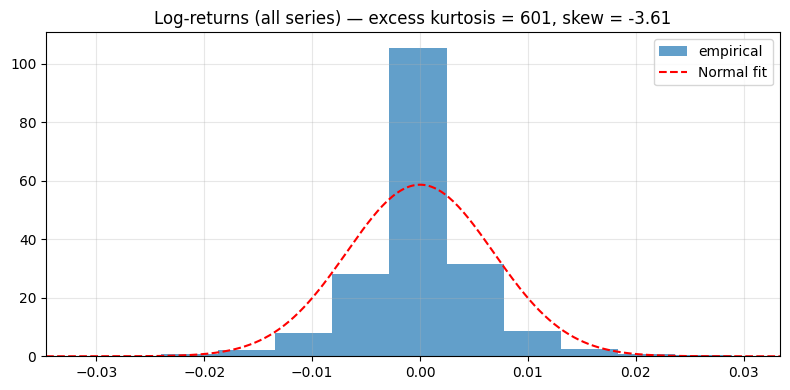

excess kurtosis = 601.4   skew = -3.610


In [7]:
allret = np.concatenate([logret(df[c].values) for c in df.columns])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(allret, bins=150, density=True, alpha=0.7, label="empirical")
xs = np.linspace(np.quantile(allret, 0.001), np.quantile(allret, 0.999), 300)
ax.plot(xs, norm.pdf(xs, allret.mean(), allret.std()), "r--", label="Normal fit")
ax.set_xlim(xs.min(), xs.max())
ax.set_title(f"Log-returns (all series) — excess kurtosis = {kurtosis(allret):.0f}, skew = {skew(allret):.2f}")
ax.legend(); fig.tight_layout(); fig.savefig(FIG / "eda_exchange_returns_dist.png", dpi=120); plt.show()
print(f"excess kurtosis = {kurtosis(allret):.1f}   skew = {skew(allret):.3f}")

The return distribution is sharply **leptokurtic** (excess kurtosis ≫ 0): a tall peak
and fat tails the Gaussian badly underfits. The huge value is driven by a few extreme
single-day jumps (a likely currency re-pegging / data break in one series). Practical
takeaways: a **Gaussian likelihood (DeepAR-Gaussian) will struggle**; Student-t or a
flexible generative model (diffusion) is better motivated; and those jumps are natural
material for the **E4 robustness** story.

## 7. Calendar seasonality? (an honest check)

In [8]:
# Timestamps are NOMINAL, so we can't trust day-of-week labels. Instead we probe
# periodicity directly in the ACF of returns at business-week / monthly lags.
a = acf(lr, nlags=30)
for k in (1, 5, 10, 21):
    print(f"ACF log-returns, lag {k:>2}: {a[k]:+.3f}")
print("\n-> No meaningful weekly (5) or monthly (21) cycle: daily FX is not calendar-seasonal,")
print("   unlike Solar/Electricity (the primary-dataset candidates), which have strong daily cycles.")

ACF log-returns, lag  1: -0.101
ACF log-returns, lag  5: +0.012
ACF log-returns, lag 10: -0.003
ACF log-returns, lag 21: +0.006

-> No meaningful weekly (5) or monthly (21) cycle: daily FX is not calendar-seasonal,
   unlike Solar/Electricity (the primary-dataset candidates), which have strong daily cycles.


This is a deliberate contrast. **Exchange tests the trend / volatility-regime axis;**
the *primary* dataset (Solar or Electricity) will test the **strong-seasonality** axis.
Together they stop us from over-fitting our conclusions to one kind of structure.

## 8. Regime-shift candidates for E4

Peak 60-day volatility at nominal 2003-03-19 (trading day 4825/7588), in the train split.


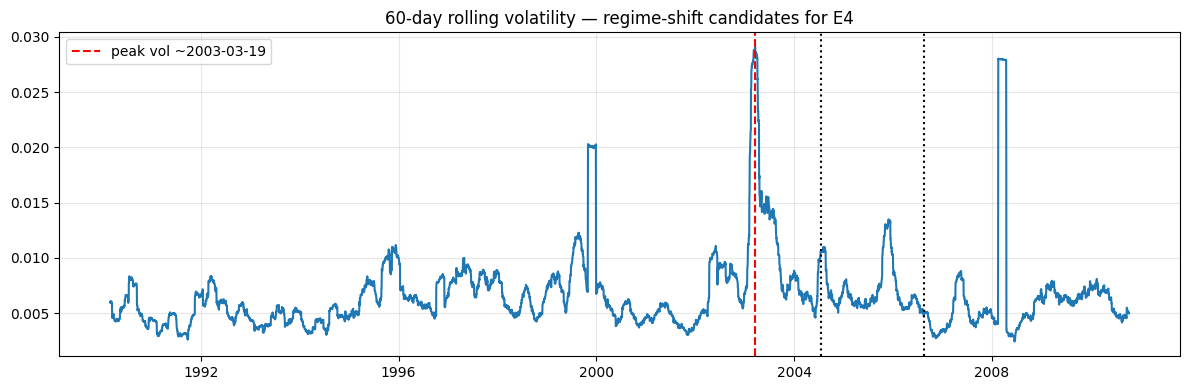

In [9]:
vol = pd.Series(lr, index=df.index[1:]).rolling(60).std()
peak = vol.idxmax(); loc = df.index.get_loc(peak)
where = "train" if loc < n_tr else ("val" if loc < n_tr + n_va else "test")
print(f"Peak 60-day volatility at nominal {peak.date()} (trading day {loc}/{len(df)}), in the {where} split.")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(vol.index, vol.values)
ax.axvline(peak, color="r", ls="--", label=f"peak vol ~{peak.date()}")
ax.axvline(df.index[n_tr], color="k", ls=":"); ax.axvline(df.index[n_tr + n_va], color="k", ls=":")
ax.set_title("60-day rolling volatility — regime-shift candidates for E4"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "eda_exchange_regimes.png", dpi=120); plt.show()

Volatility is clearly **non-stationary in regime**: long calm stretches punctuated by
turbulent bursts. For **E4** we deliberately evaluate on a test window that contains a
turbulent burst and ask whether the probabilistic models *widen* their intervals
appropriately (coverage holds) while point models degrade.

## 9. Save the headline numbers (for the report & slides)

In [10]:
stats = {
    "dataset": ds.name, "D": ds.D, "context_H": ds.H, "horizon_tau": ds.tau,
    "n_total": int(len(df)), "n_train": int(n_tr), "n_val": int(n_va), "n_test": int(n_te),
    "split_ratios": ds.meta["split_ratios"],
    "adf_p_levels_median": float(adf["adf_p_levels"].median()),
    "adf_p_logret_max": float(adf["adf_p_logret"].max()),
    "n_levels_nonstationary": int((adf["adf_p_levels"] > 0.05).sum()),
    "acf1_levels": float(acf(lv, nlags=1)[1]),
    "acf1_returns": float(acf(lr, nlags=1)[1]),
    "acf1_squared_returns": float(acf(lr ** 2, nlags=1)[1]),
    "excess_kurtosis_returns": float(kurtosis(allret)),
    "skew_returns": float(skew(allret)),
    "peak_vol_nominal_date": str(peak.date()),
    "peak_vol_split": where,
}
out = REPO / "results" / "eda_exchange_stats.json"
out.parent.mkdir(exist_ok=True)
out.write_text(json.dumps(stats, indent=2))
print("wrote", out)
stats

wrote /Users/giovannimason/Desktop/pml-diffusion-tsf/results/eda_exchange_stats.json


{'dataset': 'exchange',
 'D': 8,
 'context_H': 60,
 'horizon_tau': 30,
 'n_total': 7588,
 'n_train': 5311,
 'n_val': 758,
 'n_test': 1519,
 'split_ratios': [0.7, 0.1, 0.2],
 'adf_p_levels_median': 0.4116735722670638,
 'adf_p_logret_max': 0.0,
 'n_levels_nonstationary': 7,
 'acf1_levels': 0.9990084919365393,
 'acf1_returns': -0.10101646445027548,
 'acf1_squared_returns': 0.41524959579638554,
 'excess_kurtosis_returns': 601.368431369633,
 'skew_returns': -3.609866208499055,
 'peak_vol_nominal_date': '2003-03-19',
 'peak_vol_split': 'train'}

## Takeaways → modeling choices

| Finding | Consequence for the project |
|---|---|
| Levels near unit root (ADF non-stationary, ACF≈1) | **Naive/random-walk M0 is a hard baseline** — beating it is a real result (§5.1). |
| Returns ~white in the mean | Little linear signal in direction; ARIMA/ETS gains will be modest → motivates richer models. |
| Strong volatility clustering | Forecasts need **state-dependent interval width**; rewards calibrated probabilistic models (CRPS/coverage). |
| Heavy-tailed returns | Gaussian likelihood under-fits → prefer **Student-t / generative**; jumps feed the **E4** story. |
| No calendar seasonality | Complements a strongly-seasonal **primary** dataset (Solar/Electricity). |
| Volatility regimes | Concrete **E4** evaluation windows. |

**On `H`/`τ`.** With context `H=60` (≈ a quarter of trading days) the model sees a full
recent trend-and-volatility regime; horizon `τ=30` (≈ 6 trading weeks) is long enough
that the random-walk levels can drift materially, so calibrated uncertainty — not point
accuracy — is what separates the models. These are the defaults in
`configs/data_exchange.yaml`; the horizon sweep **E2** stress-tests them.